GitHub Repo:
https://github.com/ImmanuelOji/Last-FM-Data-Mining

## (A) Identification of Candidate Datasets

## Dataset 1 - Online Retail Dataset (UCI)

- Dataset name and source: Online Retail Dataset — UCI Machine Learning Repository
- Course topic alignment: Frequent Itemsets, Association Rule Mining
- Potential beyond-course techniques: Sequential Pattern Mining, Statistical validation of association rules
- Dataset size and structure: 500,000 transactions, Each row: Invoice, Product, Quantity, Timestamp
- Data types: Transaction ID, Product ID / Name, Timestamp, Numeric quantity
- Target variable(s): None
- Licensing or usage constraints: Public academic dataset

## Dataset 2 - Instacart Grocery Orders

- Dataset name and source: Instacart Market Basket Dataset
- Course topic alignment: Frequent Itemset Mining, Association Rules
- Potential beyond-course techniques: Sequential Pattern Mining, Recommendation modeling from rules
- Dataset size and structure: 3 million grocery orders, User → Orders → Products
- Data types: Order ID, Product ID, User ID, Timestamp / order sequence
- Target variable(s): None
- Licensing or usage constraints: Public dataset for research use

## Dataset 3 - Last.fm Music Listening Dataset

- Dataset name and source: Last.fm 1K - (GroupLens / Last.fm public dataset)
- Course topic alignment: Frequent Itemset Mining, Association Rule
- Potential beyond-course techniques: Sequential Pattern Mining, Recommendation modeling from association rules
- Dataset size and structure: 19 million listening events, User listening history over time
- Data types: User ID, Artist / Song ID, Timestamp, Listening events
- Target variable(s): None
- Licensing or usage constraints: Public academic dataset (research use allowed)

## (B) Comparative Analysis of Datasets

| Dimension | Online Retail Dataset | Instacart Grocery Dataset | Last.fm Music Listening Dataset |
|----------|----------------------|---------------------------|---------------------------------|
| **Supported Data Mining Tasks** | **Course:** Frequent Itemsets, Association Rules (market basket patterns) <br> **External:** Sequential Pattern Mining, statistical validation of rules | **Course:** Frequent Itemsets, Association Rules (grocery baskets) <br> **External:** Sequential Pattern Mining, recommendation modeling | **Course:** Frequent Itemsets, Association Rules (co-listened artists/songs) <br> **External:** Sequential Pattern Mining (temporal listening behavior), recommendation modeling |
| **Data Quality Issues** | Missing customer IDs, duplicate invoices, product cancellations, noisy product descriptions | Large dataset size, missing product metadata, order sparsity, repeated items | Requires session construction, noisy listening logs, possible missing timestamps, repeated listens |
| **Algorithmic Feasibility** | Moderate size (500K transactions); Apriori/FP-Growth feasible locally; sequential mining feasible after sampling | Very large (3M orders); may require sampling; FP-Growth feasible; sequential mining heavier | Large listening logs but can sample; FP-Growth feasible after basket construction; sequential mining manageable |
| **Bias Considerations** | Retail promotion bias, seasonal purchasing bias, customer sampling bias | Shopping habit bias, product availability bias, demographic skew | Platform-specific listening bias (Last.fm users not general population), popularity bias toward famous artists |
| **Ethical Considerations** | Low risk; anonymized transaction data | Low risk; anonymized consumer behavior | Low risk; anonymized listening data; recommendation analysis may reinforce popularity bias |


## (C) Dataset Selection

### Selected Dataset — Last.fm Music Listening Dataset

Reasons: 
- The Last.fm Music Listening Dataset was selected because it strongly supports Frequent Itemset Mining and Association Rule Mining.
- Music listening behavior naturally forms transaction-style data where songs or artists listened within a session can be treated as baskets, making it well-suited for pattern discovery.
- The dataset enables Sequential Pattern Mining, a beyond-course technique, by leveraging timestamps to analyze temporal listening behavior and uncover order-sensitive patterns that traditional itemset mining cannot capture.

Trade-offs:
- Raw listening logs may require preprocessing to construct sessions or baskets.
- Dataset is large and may require sampling for computational feasibility.
- No labeled target variable (unsupervised pattern mining).

## (D) Exploratory Data Analysis

In [14]:
#Download and extract dataset
import os
import urllib.request
import zipfile

# Dataset URL
DATA_URL = "https://files.grouplens.org/datasets/hetrec2011/hetrec2011-lastfm-2k.zip"

# Local paths
ZIP_PATH = "data/lastfm_dataset.zip"
EXTRACT_FOLDER = "data"

os.makedirs("data", exist_ok=True)

def download_dataset(url: str, to_path: str):
    if not os.path.exists(to_path):
        print(f"Downloading from {url} ...")
        urllib.request.urlretrieve(url, to_path)
        size = os.path.getsize(to_path) / (1024 * 1024)
        print(f"Saved to {to_path} ({size:.2f} MB)")
    else:
        print("Dataset already downloaded.")

def extract_required_files(zip_path: str, extract_to: str, required_files):
    print("Extracting required files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        for file in zip_ref.namelist():
            for req in required_files:
                if file.endswith(req):
                    print(f"Extracting {req} ...")
                    zip_ref.extract(file, extract_to)

    print("Extraction complete.")

# Download ZIP
download_dataset(DATA_URL, ZIP_PATH)

# Extract needed files
required_files = ["user_artists.dat", "artists.dat"]
extract_required_files(ZIP_PATH, EXTRACT_FOLDER, required_files)

Dataset already downloaded.
Extracting required files...
Extracting artists.dat ...
Extracting artists.dat ...
Extracting user_artists.dat ...
Extracting artists.dat ...
Extraction complete.


Downloaded dataset zip file and extracted the the datasets i needed('user_artist.dat','artist.dat'), and stored it in my system

In [15]:
import pandas as pd

# Load files
user_artists = pd.read_csv("data/user_artists.dat", sep="\t")
artists = pd.read_csv("data/artists.dat", sep="\t")

print("User-Artist shape:", user_artists.shape)
print("Artists shape:", artists.shape)

user_artists.head()

User-Artist shape: (92834, 3)
Artists shape: (17632, 4)


,userID,artistID,weight
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983


In [16]:
user_artists.info()

<class 'pandas.DataFrame'>
RangeIndex: 92834 entries, 0 to 92833
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   userID    92834 non-null  int64
 1   artistID  92834 non-null  int64
 2   weight    92834 non-null  int64
dtypes: int64(3)
memory usage: 2.1 MB


The Last.fm dataset contains user listening interactions with artists.
Each row represents how many times a user listened to a specific artist.

In [17]:
# checking for missing values
print("Missing values (user_artists):")
print(user_artists.isnull().sum())

print("\nMissing values (artists):")
print(artists.isnull().sum())

Missing values (user_artists):
userID      0
artistID    0
weight      0
dtype: int64

Missing values (artists):
id              0
name            0
url             0
pictureURL    444
dtype: int64


In [18]:
#Checking for duplicates
duplicates = user_artists.duplicated().sum()
print("Duplicate rows:", duplicates)

if duplicates > 0:
    user_artists = user_artists.drop_duplicates()
    print("Duplicates removed.")

Duplicate rows: 0


The dataset required minimal cleaning. No missing values were present in the
`user_artists` table, and duplicate records were not detected. The `pictureURL`
column in the `artists` table contained missing values, but this column is not
relevant to frequent itemset or association rule mining and was therefore ignored.

In [19]:
#Merge Artist Names
data = user_artists.merge(artists, left_on="artistID", right_on="id", how="left")

#transaction basket
baskets = data.groupby("userID")["name"].apply(list)

In [20]:
data.head()

,userID,artistID,weight,id,name,url,pictureURL
0,2,51,13883,51,Duran Duran,http://www.last.fm/music/Duran+Duran,http://userserve-ak.last.fm/serve/252/155668.jpg
1,2,52,11690,52,Morcheeba,http://www.last.fm/music/Morcheeba,http://userserve-ak.last.fm/serve/252/46005111...
2,2,53,11351,53,Air,http://www.last.fm/music/Air,http://userserve-ak.last.fm/serve/252/251119.jpg
3,2,54,10300,54,Hooverphonic,http://www.last.fm/music/Hooverphonic,http://userserve-ak.last.fm/serve/252/40553471...
4,2,55,8983,55,Kylie Minogue,http://www.last.fm/music/Kylie+Minogue,http://userserve-ak.last.fm/serve/252/12740835...


In [21]:
baskets.head()

userID
2    [Duran Duran, Morcheeba, Air, Hooverphonic, Ky...
3    [Pleq, Segue, Max Richter, Celer, Pjusk, Pleq ...
4    [Duran Duran, Air, Röyksopp, Coldplay, Moby, D...
5    [Air, Radiohead, Placebo, Keane, Muse, The Tig...
6    [George Michael, Keyshia Cole, Racionais MC's,...
Name: name, dtype: object

Merged the user_artists with artists to get their names then contructed a transaction basket. Each user is treated as a transaction, and the artists listened to by that user
form the item basket.

In [22]:
#number of users, artists and total listening records
print("Number of users:", data["userID"].nunique())
print("Number of artists:", data["name"].nunique())
print("Total listening records:", len(data))

Number of users: 1892
Number of artists: 17632
Total listening records: 92834


In [23]:
#EDA on basket size
basket_sizes = baskets.apply(len)

print("Average basket size:", basket_sizes.mean())
print("Median basket size:", basket_sizes.median())
print("Max basket size:", basket_sizes.max())
print("Min basket size:", basket_sizes.min())

Average basket size: 49.06659619450317
Median basket size: 50.0
Max basket size: 50
Min basket size: 1


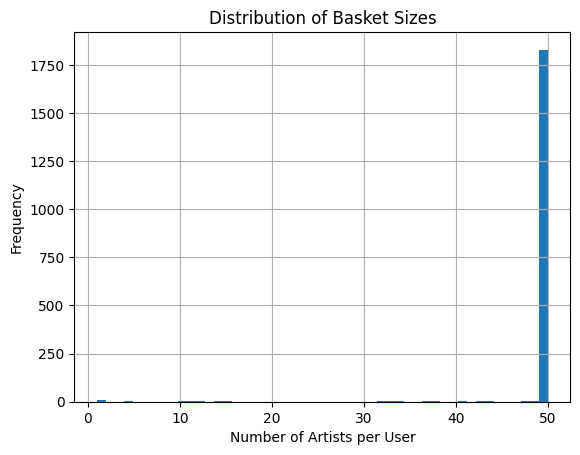

In [24]:
#Basket Size Distribution
import matplotlib.pyplot as plt

basket_sizes.hist(bins=50)
plt.title("Distribution of Basket Sizes")
plt.xlabel("Number of Artists per User")
plt.ylabel("Frequency")
plt.show()

In [25]:
#most popular artist
top_artists = data["name"].value_counts().head(20)
top_artists

name
Lady Gaga             611
Britney Spears        522
Rihanna               484
The Beatles           480
Katy Perry            473
Madonna               429
Avril Lavigne         417
Christina Aguilera    407
Muse                  400
Paramore              399
Beyoncé               397
Radiohead             393
Coldplay              369
Ke$ha                 362
Shakira               319
P!nk                  305
The Killers           304
Black Eyed Peas       304
Kylie Minogue         298
Miley Cyrus           286
Name: count, dtype: int64

The histogram shows the distribution of the number of artists listened to by each user. Most users have baskets containing approximately 50 artists, as indicated by the large peak near the upper range. Only a small number of users have very small baskets.The distribution suggests relatively consistent listening diversity across users.

### Bias Considerations

The Last.fm dataset reflects listening behavior of users on the Last.fm platform,
which may not represent the general population. The dataset may exhibit popularity
bias, where highly popular artists appear more frequently, potentially dominating
frequent itemsets and association rules. Additionally, user activity levels vary,
and highly active users may disproportionately influence discovered patterns.

### Initial Observations

- Basket sizes vary widely across users, indicating differences in listening diversity.
- A small number of artists dominate listening frequency, suggesting strong popularity bias.
- Most users listen to a limited subset of artists, resulting in sparse co-listening patterns.

### Hypotheses

- Highly popular artists will form strong frequent itemsets due to widespread listening.
- Rare artists may still form meaningful sequential patterns which will not captured by traditional itemset mining.

### Research Questions

1. What frequent artist combinations appear across users?
2. How do different support thresholds affect discovered association rules?
3. Do sequential listening patterns reveal structure beyond traditional frequent itemsets?
4. Can association rules be used to generate meaningful music recommendation patterns?
5. Will it be better to do the music recommendation with types of songs and not artists?

## Research Questions Formation
### Project Scope

### Dataset
This project uses the Last.fm HetRec 2011 dataset, which contains anonymized user listening interactions with music artists. Each record represents the listening frequency of a user for a specific artist.

### Transaction Representation
For frequent itemset mining, each user is treated as a transaction, and the set of artists listened to by the user forms the item basket.

### Exploratory Data Analysis Summary
Initial exploratory analysis revealed:

- No missing values in the main interaction dataset.
- Artist popularity follows a long-tail distribution, where a small number of artists dominate listening frequency.
- Basket sizes are relatively consistent across users, with most users listening to around 50 artists.
- Listening behavior suggests strong popularity bias toward certain artists.

### Techniques
Course techniques:
- Frequent Itemset Mining
- Association Rule Mining

External technique:
- Sequential Pattern Mining

## Research Questions

### RQ1
Do highly popular artists dominate frequent itemsets, and how does this affect pattern diversity?

### RQ2
Can association rules be used to generate meaningful music recommendations, and how interpretable are these recommendations?

### RQ3
How does sequential patterns differ from frequent itemsets in capturing user listening behavior?

## RQ–Method Mapping

| Research Question | Data Mining Task | Algorithms | Evaluation Criteria |
|------------------|-----------------|-----------|--------------------|
| RQ1: Popularity dominance in itemsets | Frequent Itemset Mining | FP-Growth | Support, pattern diversity, frequency distribution |
| RQ2: Recommendation via rules | Association Rule Mining | FP-Growth + rule generation | Confidence, Lift, Interpretability |
| RQ3: Sequential vs unordered patterns | Sequential Pattern Mining | PrefixSpan (external) | Sequence support, pattern uniqueness, interpretability |

## Log-Scale Distribution

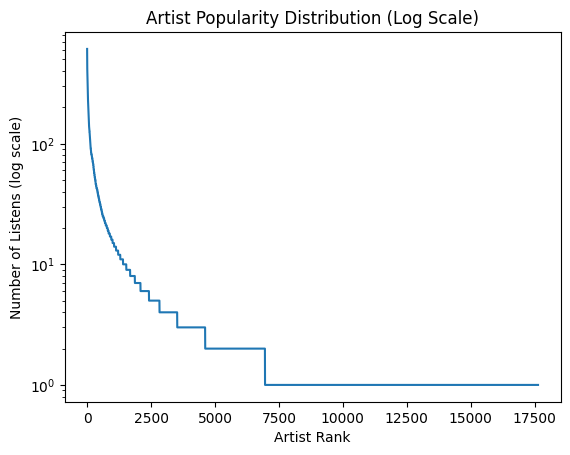

In [28]:
artist_counts = data["name"].value_counts()

plt.figure()
plt.plot(artist_counts.values)
plt.yscale("log")
plt.title("Artist Popularity Distribution (Log Scale)")
plt.xlabel("Artist Rank")
plt.ylabel("Number of Listens (log scale)")
plt.show()

### Additional EDA: Artist Popularity Log-Scale Distribution

To further analyze popularity bias, the distribution of artist listening frequency was examined using a log-scale visualization.

The results show a clear long-tail distribution, where a small number of artists receive a very high number of listens, while the majority of artists have very low listening counts. The steep decline in the curve followed by a long flat tail confirms strong popularity imbalance in the dataset.

This indicates that listening behavior is heavily concentrated around a few popular artists, which may lead to dominance of these artists in frequent itemsets and association rules.

This observation motivates RQ1, which investigates whether highly popular artists dominate frequent itemsets and how this affects the diversity of discovered patterns.

## Motivation and Feasibility

### Motivation
EDA reveals a strong long-tail distribution in artist popularity, suggesting that frequent itemsets may be dominated by highly popular artists. This raises questions about the diversity and usefulness of discovered patterns.

Additionally, music listening behavior is inherently sequential, but frequent itemset mining ignores temporal order. This motivates the use of sequential pattern mining to uncover patterns that may not be captured by unordered methods.

### Non-Triviality
Frequent itemset and association rule mining focus on co-occurrence but ignore order and temporal relationships. Sequential pattern mining introduces additional complexity by considering the order of events, potentially revealing deeper behavioral patterns.

### Feasibility
The dataset is of manageable size, and sampling can be applied if necessary. Efficient algorithms such as FP-Growth and PrefixSpan are available in Python libraries, making both course and external techniques implementable.

### Risks
- Popular artists may dominate frequent patterns, reducing diversity
- Sequential pattern mining may be sensitive to parameter choices

## Methodological Plan

### Course Algorithms
- FP-Growth for frequent itemset mining
- Association rule generation using support, confidence, and lift

### External Algorithm
- PrefixSpan for sequential pattern mining

### Evaluation Strategy
Patterns will be evaluated using:

- Support (frequency of occurrence)
- Confidence (rule reliability)
- Lift (strength of association beyond independence)
- Interpretability (human-understandable patterns)

### Baseline
High-support frequent itemsets will serve as a baseline for evaluating improvements from sequential pattern mining.

## RQ1 Highly Popular Artist Dominate Frequent Itemsets?

In [31]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(baskets).transform(baskets)

basket_df = pd.DataFrame(te_array, columns=te.columns_)

print(basket_df.shape)
basket_df.iloc[:5, :10]

(1892, 17632)


,!!!,!DISTAIN,!deladap,#####,#2 Orchestra,$lick,$lick feat. Six-Fo,(1962-1966),(Pre) Kingdom,(We Are) Performance
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False


### Data Preparation for Frequent Itemset Mining

The transaction data was transformed into a one-hot encoded matrix where each row represents a user and each column represents an artist. A value of `True` indicates that the artist appears in the user's listening basket.

This format is required for applying frequent itemset mining FP-Growth algorithm.

In [32]:
#Running FP- Growth
from mlxtend.frequent_patterns import fpgrowth

frequent_itemsets = fpgrowth(basket_df, min_support=0.05, use_colnames=True)

frequent_itemsets.sort_values(by="support", ascending=False).head(10)

,support,itemsets
0,0.322939,frozenset({Lady Gaga})
37,0.275899,frozenset({Britney Spears})
38,0.255814,frozenset({Rihanna})
19,0.253700,frozenset({The Beatles})
39,0.250000,frozenset({Katy Perry})
1577,0.230444,"frozenset({Lady Gaga, Britney Spears})"
1,0.226744,frozenset({Madonna})
40,0.220402,frozenset({Avril Lavigne})
1578,0.218816,"frozenset({Lady Gaga, Rihanna})"
1579,0.218288,"frozenset({Britney Spears, Rihanna})"


### Frequent Itemset Mining (FP-Growth)

The FP-Growth algorithm was used to identify frequent sets of artists that commonly appear together in user listening behavior. A minimum support threshold was applied to filter meaningful patterns.

### Interpretation of Frequent Itemsets

The frequent itemsets are dominated by highly popular artists such as Lady Gaga, Britney Spears, and Rihanna. These artists appear frequently both as individual items and in combinations.

This confirms that popularity strongly influences frequent itemset mining, as artists with higher overall listening frequency are more likely to meet the support threshold.

As a result, pattern diversity is reduced, since less popular artists rarely appear in frequent itemsets.

## RQ2 Can Association rules be used to generate meaningful music recommendations?

In [35]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

rules.sort_values(by="lift", ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
13810,"frozenset({Christina Aguilera, Kylie Minogue, ...","frozenset({Madonna, P!nk, Rihanna})",0.078753,0.081395,0.050211,0.637584,7.833174,1.0,0.043801,2.534668,0.946909,0.456731,0.605471,0.627234
13804,"frozenset({Madonna, P!nk, Rihanna})","frozenset({Christina Aguilera, Kylie Minogue, ...",0.081395,0.078753,0.050211,0.616883,7.833174,1.0,0.043801,2.404612,0.949634,0.456731,0.584132,0.627234
17314,"frozenset({Beyoncé, Ke$ha, Kylie Minogue, Brit...","frozenset({Madonna, Christina Aguilera, Katy P...",0.066068,0.100423,0.051797,0.784000,7.806989,1.0,0.045162,4.164709,0.933590,0.451613,0.759887,0.649895
17304,"frozenset({Madonna, Christina Aguilera, Katy P...","frozenset({Beyoncé, Ke$ha, Kylie Minogue, Brit...",0.100423,0.066068,0.051797,0.515789,7.806989,1.0,0.045162,1.928773,0.969244,0.451613,0.481536,0.649895
17259,"frozenset({Madonna, Christina Aguilera, Katy P...","frozenset({Beyoncé, Ke$ha, Kylie Minogue})",0.098309,0.067653,0.051797,0.526882,7.787970,1.0,0.045146,1.970642,0.966624,0.453704,0.492551,0.646253
17341,"frozenset({Beyoncé, Ke$ha, Kylie Minogue})","frozenset({Madonna, Christina Aguilera, Katy P...",0.067653,0.098309,0.051797,0.765625,7.787970,1.0,0.045146,3.847216,0.934842,0.453704,0.740072,0.646253
153412,"frozenset({Lady Gaga, Ke$ha, Shakira, Rihanna,...","frozenset({Miley Cyrus, Christina Aguilera, Be...",0.085095,0.077167,0.050211,0.590062,7.646558,1.0,0.043645,2.251153,0.950068,0.448113,0.555783,0.620374
153430,"frozenset({Miley Cyrus, Christina Aguilera, Be...","frozenset({Lady Gaga, Ke$ha, Shakira, Rihanna,...",0.077167,0.085095,0.050211,0.650685,7.646558,1.0,0.043645,2.619139,0.941906,0.448113,0.618195,0.620374
151841,"frozenset({Miley Cyrus, Christina Aguilera, Be...","frozenset({Ke$ha, Britney Spears, Shakira, Rih...",0.077167,0.091438,0.053911,0.698630,7.640510,1.0,0.046855,3.014775,0.941794,0.470046,0.668300,0.644113
151886,"frozenset({Ke$ha, Britney Spears, Shakira, Rih...","frozenset({Miley Cyrus, Christina Aguilera, Be...",0.091438,0.077167,0.053911,0.589595,7.640510,1.0,0.046855,2.248593,0.956587,0.470046,0.555277,0.644113


### Interpretation of Association Rules

Association rules reveal relationships between artists based on co-listening behavior. For example, a rule such as:

{Artist A, Artist B} → {Artist C}

indicates that users who listen to Artist A and Artist B are likely to also listen to Artist C.

The confidence metric measures how often the rule holds, while lift evaluates how strong the relationship is compared to random chance. High lift values observed in the results indicate strong associations between artists.

A confidence threshold of 0.5 was used to ensure that only reliable and meaningful rules were retained. This means that at least 50% of users who satisfy the antecedent also satisfy the consequent.

The results show that many association rules involve popular artists such as Madonna, Rihanna, and Britney Spears, indicating that recommendation patterns are influenced by popularity bias. 

However, the rules also capture meaningful multi-artist relationships with high lift values, suggesting that these associations reflect structured co-listening behavior rather than purely random popularity effects. 

While the rules are strong and interpretable, their diversity may still be limited due to the dominance of widely listened artists.

### From the results

From the first row on the table
{Christina Aguilera, Kylie Minogue} → {Madonna, P!nk, Rihanna}
confidence = 0.637
lift = 7.83
support = 0.050

This means that if a user listens to Christina Aguilera and Kylie Minogue, then they are likely to also listen to Madonna, P!nk, and Rihanna.
- support = 0.050 - 5% of ALL users listened to ALL of these artists together
- confidence = 0.63 - Among users who listened to Christina Aguilera and Kylie Minogue, 63% listened to Madonna, P!nk, and Rihanna.
That shows that yes this can be used to generate meaning good music recommendations.
- lift = 7.83 - These artists are specifically listened to together, not just randomly popular.

## RQ3 How does sequential patterns differ from frequent itemsets in capturing user listening behavior?

In [39]:
from prefixspan import PrefixSpan

#subset
sample_sequences = baskets.head(300).tolist()

ps = PrefixSpan(sample_sequences)

# Find frequent sequences
seq_patterns = ps.frequent(10)  # min support = 10 users

seq_patterns[:10]

[(27, ['Duran Duran']),
 (11, ['Duran Duran', 'New Order']),
 (10, ['Duran Duran', 'New Order', 'Depeche Mode']),
 (10, ['Duran Duran', 'Coldplay']),
 (10, ['Duran Duran', 'Madonna']),
 (19, ['Duran Duran', 'Depeche Mode']),
 (10, ['Duran Duran', 'Depeche Mode', 'The Cure']),
 (10, ['Duran Duran', 'Depeche Mode', 'a-ha']),
 (13, ['Duran Duran', 'The Cure']),
 (12, ['Duran Duran', 'a-ha'])]

Sequential pattern mining was applied using the PrefixSpan algorithm to identify ordered listening patterns. Unlike frequent itemsets, this method considers the order of artist occurrences.

Increasing the minimum support threshold reduces the number of discovered patterns while increasing their strength and reliability. Lower support thresholds reveal more diverse but less frequent patterns, whereas higher thresholds focus on dominant and repetitive behavior.

A moderate support threshold was chosen to balance pattern diversity and computational efficiency.

A subset of 300 users was used to ensure computational feasibility while preserving representative listening patterns. Sequential pattern mining is computationally expensive, and this subset provides a balance between efficiency and meaningful pattern discovery.

From the result here we can see a pattern of how users listen to artists and who they listen to next, we can use this to make good music recommendations.

## Conclusion

This project demonstrated that frequent itemset mining and association rule mining can uncover meaningful patterns in music listening behavior, but are strongly influenced by popularity bias.

Sequential pattern mining provides additional insight by capturing the order of listening behavior, revealing structured user patterns that are not visible through unordered methods.

This means Sequential pattern mining looks at the order in which users listen to artists, and this helps us see patterns that we wouldn’t see if we only looked at which artists appear together.

It considers the order in which users listen to artists, allowing us to identify patterns such as users moving from one artist to another. This reveals structured listening behavior that cannot be captured by frequent itemsets, which only consider whether artists appear together without any order.

- Itemsets = what people like together
- Sequences = how people behave over time

On my honor, I declare the following resources:
1. Web Sources:
- https://files.grouplens.org/datasets/hetrec2011/hetrec2011-lastfm-2k.zip - Data Source

2. AI Tools:
- ChatGPT: Asked it to give me a list of websites and resources i can find a dataset i can use for this project and after checking all the options i chose one. Also shared my ideas on how i wanted to do certain things in the project and asked the best way to do it, like the best way to show the long tail distribution, Gave me certain options and i chose to use the Log Scale Distribution